# Lab: Data exploration

---

<a id="learning-objectives"></a>
## Learning Objectives
*After completing this lab, you will be able to:*

- Explore and interrogate different data sets using our pandas and matplotlib.
- Interpret the findings to understand what the data tells us about the real world.

<a id="coffee"></a>

# <font color='blue'> Coffee shop data</font>

## Part A

In this Lab we'll be working with one datasets.
    
The dataset consists of coffee shop transactions, a dataset created by IBM and made available on [Kaggle](https://www.kaggle.com/datasets/ylchang/coffee-shop-sample-data-1113).

The data consists of coffee shop transactions in April 2019.

There are ~50,000 total transactions in the data set. The data consists of transactions from shops in New York City only.

Our task is to answer 3 questions:
1. **Which products offer the best margins?**
2. **Are particular customer groups spending more?**
3. **Which products generate the most sales?**

<br />

Let's start by reading in the data as a pandas `DataFrame` called `coffee_df`.

In [239]:
# Importing needed library
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import date

##### 1.❓ Next, let's read in the data as a pandas `DataFrame` called `coffee_df`

In [179]:
coffee_df = pd.read_csv('./data/coffee_shop_lab.csv')

##### 2.❓Now preview the first 5 rows of the data.

In [180]:
coffee_df.head()

,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation
0,2019-04-01,12:04:43,558.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-06-19,1983.0,Older Millennials
1,2019-04-01,11:15:38,22.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-03-03,1953.0,Baby Boomers
2,2019-04-01,12:05:31,659.0,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2019-01-14,1996.0,Gen Z
3,2019-04-01,16:49:38,407.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-08-11,1963.0,Baby Boomers
4,2019-04-01,19:17:34,537.0,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-05-06,1980.0,Older Millennials


##### 3.❓ How many rows and columns does the dataset have?

In [181]:
coffee_df.shape

(49894, 13)

##### 4.❓ Check the type of data in each column- do you notice any problems?

In [182]:
coffee_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49894 entries, 0 to 49893
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_date         49894 non-null  str    
 1   transaction_time         49894 non-null  str    
 2   customer_id              24861 non-null  float64
 3   quantity                 49894 non-null  int64  
 4   line_item_amount         49894 non-null  float64
 5   unit_price               49894 non-null  float64
 6   product_group            49894 non-null  str    
 7   product_category         49894 non-null  str    
 8   product_type             49894 non-null  str    
 9   current_wholesale_price  49894 non-null  float64
 10  customer_since           24852 non-null  str    
 11  customer_birth_year      24852 non-null  float64
 12  customer_generation      24852 non-null  str    
dtypes: float64(5), int64(1), str(7)
memory usage: 7.7 MB


> 👉 **Write Your Findings Here**: 
-- -

##### 5.❓ You might have noticed earlier when running the `dtypes` command that the `transaction_date` and `customer_since` columns are currently being treated like strings. We need to convert them into date columns so we can calculate factors like how long someone's been a customer.

Try using pd.to_datetime() to convert these two columns to date representations

In [183]:
coffee_df['transaction_date'] = pd.to_datetime(coffee_df['transaction_date'])
coffee_df['customer_since'] = pd.to_datetime(coffee_df['customer_since'])
coffee_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49894 entries, 0 to 49893
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   transaction_date         49894 non-null  datetime64[us]
 1   transaction_time         49894 non-null  str           
 2   customer_id              24861 non-null  float64       
 3   quantity                 49894 non-null  int64         
 4   line_item_amount         49894 non-null  float64       
 5   unit_price               49894 non-null  float64       
 6   product_group            49894 non-null  str           
 7   product_category         49894 non-null  str           
 8   product_type             49894 non-null  str           
 9   current_wholesale_price  49894 non-null  float64       
 10  customer_since           24852 non-null  datetime64[us]
 11  customer_birth_year      24852 non-null  float64       
 12  customer_generation      24852 non-null  st

##### 6.❓ Examine the percentage of missing values in each column. What might these missing values represent? How would you suggest handling them?



In [184]:
coffee_df.isna().mean()*100

transaction_date            0.000000
transaction_time            0.000000
customer_id                50.172365
quantity                    0.000000
line_item_amount            0.000000
unit_price                  0.000000
product_group               0.000000
product_category            0.000000
product_type                0.000000
current_wholesale_price     0.000000
customer_since             50.190404
customer_birth_year        50.190404
customer_generation        50.190404
dtype: float64

👉 Since more than 50% of the customer-related data is missing

👉 The missing values in the customer-related columns of your coffee dataset could represent:

- Guest Customers 
- Incomplete Data Collection 
- Data Integration Issues
  

👉 Is the missing values essentials to your analysis? 
- If necessary:
    - consider finding the missing values
    - Or, create a dataset that contains the rows that have filled information and discard the rows that have null values for that customer-related columns.

- If not necessary in your analysis, just ignore them

##### 7.❓ Check for duplicate values, and remove them if any.

In [185]:
# how many duplicates we have
coffee_df.duplicated().sum()

np.int64(149)

In [186]:
# Remove the duplicates and check if the total duplicates is 0 now
coffee_df = coffee_df.drop_duplicates()

In [187]:
coffee_df.shape

(49745, 13)

##### 8.❓ Explore the unique values in all the categorical columns:
- product group
- product category
- product type
- customer_generation

1. What inconsistencies do you notice?
2. Is there a spelling consistency?
3. Do you need to fix anything?

In [188]:
# unique values in product group
coffee_df['product_group'].unique()

<ArrowStringArray>
['Beverages', 'Food', 'Whole Bean/Teas', 'Add-ons', 'Merchandise']
Length: 5, dtype: str

In [189]:
# unique values in product category
coffee_df['product_category'].unique()

<ArrowStringArray>
[               'Tea',             'Coffee', 'Drinking Chocolate',
             'Bakery',       'Coffee beans',           'Flavours',
          'Loose Tea', 'Packaged Chocolate',            'Branded']
Length: 9, dtype: str

In [190]:
# unique values in product type
coffee_df['product_type'].unique()

<ArrowStringArray>
[      'Brewed Chai tea', 'Organic brewed coffee',      'Brewed Green tea',
           'Drip coffee', 'Premium brewed coffee', 'Gourmet brewed coffee',
      'Brewed Black tea',         'Hot chocolate',      'Barista Espresso',
                 'Scone',     'Brewed herbal tea',              'Biscotti',
                'Pastry',         'Organic Beans',         'Regular syrup',
            'Herbal tea',         'Gourmet Beans',             'Black tea',
      'Sugar free syrup',     'House blend Beans',         'Premium Beans',
              'Chai tea',     'Organic Chocolate',    'Drinking Chocolate',
           'Green beans',             'Green tea',        'Espresso Beans',
            'Housewares',              'Clothing']
Length: 29, dtype: str

In [191]:
# unique values in customer_generation
coffee_df['customer_generation'].unique()

<ArrowStringArray>
[  'Older Millennials',        'Baby Boomers',               'Gen Z',
               'Gen X', 'Younger Millennials',                   nan]
Length: 6, dtype: str

##### 9.❓The `describe()` method is a handy way of accessing summary statistics for an entire `DataFrame` in one go. Try running it on your `DataFrame`:


In [192]:
coffee_df.describe()

,transaction_date,customer_id,quantity,line_item_amount,unit_price,current_wholesale_price,customer_since,customer_birth_year
count,49745,24801.000000,49745.000000,49745.000000,49745.000000,49745.000000,24792,24792.000000
mean,2019-04-15 01:25:20.257312,4582.647837,1.439481,4.687731,3.384018,1.354957,2018-02-21 06:10:48.209099,1978.248871
min,2019-04-01 00:00:00,1.000000,1.000000,0.000000,0.800000,0.040000,2017-01-03 00:00:00,1950.000000
25%,2019-04-08 00:00:00,584.000000,1.000000,3.000000,2.500000,0.600000,2017-08-05 00:00:00,1965.000000
50%,2019-04-15 00:00:00,5417.000000,1.000000,3.750000,3.000000,0.750000,2018-02-22 00:00:00,1981.000000
75%,2019-04-22 00:00:00,8099.000000,2.000000,6.000000,3.750000,1.950000,2018-09-16 00:00:00,1992.000000
max,2019-04-29 00:00:00,8501.000000,8.000000,360.000000,45.000000,36.000000,2019-04-09 00:00:00,2001.000000
std,NaN,3247.554091,0.543316,4.441833,2.686402,2.204466,NaN,15.088333


##### 10.❓What is your findings about the above summery statistics?

> Write your findings here:

👉 The `line_item_amount` column has a minimum value of 0, which seems unusual. This could indicate potential error values.

👉 The quantity column appears to be right-skewed, with 75% of orders containing only two products, while the maximum quantity is 8.

- Let's start to clean up our dataset and answer the questions in our analysis.

- We have the total line item amount (the retail price) as well as the wholesale price of the product.

- We want to calculate the **total wholesale line item amount** so we can use it to calculate profit.

##### 11.❓Can you combine the existing wholesale amount and quantity columns to create a new column in the `DataFrame` called `total_wholesale_amount` which holds the new values?

In [193]:
coffee_df['total_wholesale_amount'] = coffee_df['current_wholesale_price']*coffee_df['quantity']
coffee_df.head()

,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation,total_wholesale_amount
0,2019-04-01,12:04:43,558.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-06-19,1983.0,Older Millennials,0.63
1,2019-04-01,11:15:38,22.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-03-03,1953.0,Baby Boomers,0.63
2,2019-04-01,12:05:31,659.0,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2019-01-14,1996.0,Gen Z,1.26
3,2019-04-01,16:49:38,407.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-08-11,1963.0,Baby Boomers,0.63
4,2019-04-01,19:17:34,537.0,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-05-06,1980.0,Older Millennials,1.26


##### 12.❓Can you now create a new column called `profit` which shows the difference between the wholesale price and retail price(line_item_amount)?

In [194]:
coffee_df['profit'] = coffee_df['line_item_amount'] - coffee_df['total_wholesale_amount']
coffee_df.head()

,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation,total_wholesale_amount,profit
0,2019-04-01,12:04:43,558.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-06-19,1983.0,Older Millennials,0.63,1.87
1,2019-04-01,11:15:38,22.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-03-03,1953.0,Baby Boomers,0.63,1.87
2,2019-04-01,12:05:31,659.0,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2019-01-14,1996.0,Gen Z,1.26,3.74
3,2019-04-01,16:49:38,407.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-08-11,1963.0,Baby Boomers,0.63,1.87
4,2019-04-01,19:17:34,537.0,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-05-06,1980.0,Older Millennials,1.26,3.74


##### 13.❓Find the highest sale price in the dataset.

In [195]:
coffee_df['line_item_amount'].max()

np.float64(360.0)

In [196]:
coffee_df['unit_price'].max()

np.float64(45.0)

##### 14.❓Find the largest amount of profit.

In [197]:
coffee_df['profit'].max()

np.float64(72.0)

The largest profit is significant - but it's obviously not representative of how much profit is made on each transaction on average.

##### 15.❓Find the mean of all the profit.

In [198]:
coffee_df['profit'].mean()

np.float64(2.9367379636144335)

##### 16.❓Now, let's start filtering our data by writing logical tests. How many transactions were valued above the **mean** transaction amount?

In [199]:
(coffee_df['line_item_amount'] > coffee_df['line_item_amount'].mean()).shape[0]

49745

##### 17.❓Create a new column called `profit_ratio` which shows the ratio between the wholesale and retail prices.

In [200]:
coffee_df['profit_ratio'] = coffee_df['line_item_amount'] / coffee_df['total_wholesale_amount']
coffee_df.head()

,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation,total_wholesale_amount,profit,profit_ratio
0,2019-04-01,12:04:43,558.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-06-19,1983.0,Older Millennials,0.63,1.87,3.968254
1,2019-04-01,11:15:38,22.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-03-03,1953.0,Baby Boomers,0.63,1.87,3.968254
2,2019-04-01,12:05:31,659.0,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2019-01-14,1996.0,Gen Z,1.26,3.74,3.968254
3,2019-04-01,16:49:38,407.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-08-11,1963.0,Baby Boomers,0.63,1.87,3.968254
4,2019-04-01,19:17:34,537.0,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-05-06,1980.0,Older Millennials,1.26,3.74,3.968254


##### 18.❓Based on profit ratio, How many transactions made a profit of at least 2 times their wholesale cost?

In [201]:
coffee_df[coffee_df['profit_ratio'] >= coffee_df['total_wholesale_amount']*2].shape[0]

36738

##### 19.❓How many transactions in the dataset were for coffee `beans`? You'll have to think creatively about where this information is stored in the dataset, and how to extract it.

In [202]:
coffee_df[coffee_df['product_category'] == 'Coffee beans'].shape[0]

587

##### 20.❓Sort the dataset in descending order of profit, to find the transaction that generated the highest profit.

In [203]:
coffee_df.sort_values('profit',ascending = False).head(1)

,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation,total_wholesale_amount,profit,profit_ratio
49092,2019-04-17,09:55:47,NaN,8,360.0,45.0,Whole Bean/Teas,Coffee beans,Premium Beans,36.0,NaT,NaN,NaN,288.0,72.0,1.25


##### 21.❓Did any transactions make a loss where the profit is less than 0?


In [204]:
coffee_df[coffee_df['profit'] < 0]

,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation,total_wholesale_amount,profit,profit_ratio
37654,2019-04-07,07:00:50,5211.0,1,1.0,3.75,Food,Bakery,Pastry,2.44,2018-07-01,1994.0,Younger Millennials,2.44,-1.44,0.409836
37656,2019-04-07,08:06:36,5531.0,1,1.0,3.75,Food,Bakery,Pastry,2.44,2017-02-23,1953.0,Baby Boomers,2.44,-1.44,0.409836
37658,2019-04-07,08:39:48,5736.0,1,1.0,3.75,Food,Bakery,Pastry,2.44,2017-01-04,1980.0,Older Millennials,2.44,-1.44,0.409836
37659,2019-04-07,10:10:26,5563.0,1,1.0,3.75,Food,Bakery,Pastry,2.44,2019-01-01,1998.0,Gen Z,2.44,-1.44,0.409836
37662,2019-04-07,10:29:12,5083.0,1,1.0,3.75,Food,Bakery,Pastry,2.44,2019-02-10,1999.0,Gen Z,2.44,-1.44,0.409836
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45386,2019-04-26,10:43:19,5235.0,3,0.0,2.65,Food,Bakery,Scone,2.11,2017-07-19,1962.0,Baby Boomers,6.33,-6.33,0.000000
45390,2019-04-26,07:53:09,NaN,1,0.0,2.65,Food,Bakery,Scone,2.11,NaT,NaN,NaN,2.11,-2.11,0.000000
45395,2019-04-26,12:51:58,5180.0,3,0.0,2.65,Food,Bakery,Scone,2.11,2018-11-19,1997.0,Gen Z,6.33,-6.33,0.000000
46267,2019-04-07,09:42:52,5033.0,1,12.0,12.00,Whole Bean/Teas,Coffee beans,Organic Beans,18.00,2018-02-10,1975.0,Gen X,18.00,-6.00,0.666667


- Look at the above result of transactions that made loss.
You might notice some oddities when answering this question. Are all the rows you identified genuine losses or data errors?
* Hint: is there anything that does not show the correct result of line_item_amount?
* Note: line_item_amount = unit_price * quantity


##### Write your findindg here please:
- 

##### 22.❓Correct the line item amount column with the correct values

In [205]:
coffee_df['line_item_amount'] = coffee_df['unit_price']*coffee_df['quantity']
coffee_df

,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation,total_wholesale_amount,profit,profit_ratio
0,2019-04-01,12:04:43,558.0,1,2.50,2.50,Beverages,Tea,Brewed Chai tea,0.63,2018-06-19,1983.0,Older Millennials,0.63,1.87,3.968254
1,2019-04-01,11:15:38,22.0,1,2.50,2.50,Beverages,Tea,Brewed Chai tea,0.63,2017-03-03,1953.0,Baby Boomers,0.63,1.87,3.968254
2,2019-04-01,12:05:31,659.0,2,5.00,2.50,Beverages,Tea,Brewed Chai tea,0.63,2019-01-14,1996.0,Gen Z,1.26,3.74,3.968254
3,2019-04-01,16:49:38,407.0,1,2.50,2.50,Beverages,Tea,Brewed Chai tea,0.63,2017-08-11,1963.0,Baby Boomers,0.63,1.87,3.968254
4,2019-04-01,19:17:34,537.0,2,5.00,2.50,Beverages,Tea,Brewed Chai tea,0.63,2018-05-06,1980.0,Older Millennials,1.26,3.74,3.968254
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49889,2019-04-24,09:31:54,8113.0,1,8.95,8.95,Whole Bean/Teas,Loose Tea,Herbal tea,7.16,2017-01-08,1998.0,Gen Z,7.16,1.79,1.250000
49890,2019-04-25,06:17:12,5778.0,1,8.95,8.95,Whole Bean/Teas,Loose Tea,Herbal tea,7.16,2017-04-08,1956.0,Baby Boomers,7.16,1.79,1.250000
49891,2019-04-25,10:48:21,NaN,1,8.95,8.95,Whole Bean/Teas,Loose Tea,Herbal tea,7.16,NaT,NaN,NaN,7.16,1.79,1.250000
49892,2019-04-25,08:54:27,8039.0,1,8.95,8.95,Whole Bean/Teas,Loose Tea,Herbal tea,7.16,2017-06-26,1963.0,Baby Boomers,7.16,1.79,1.250000


##### 23.❓Re-calculate the profit column that you did earlier to fix the profit value after you corrected the line_item_amount column you did in the previous step

In [206]:
coffee_df['profit'] = coffee_df['line_item_amount'] - coffee_df['total_wholesale_amount']
coffee_df.head()

,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation,total_wholesale_amount,profit,profit_ratio
0,2019-04-01,12:04:43,558.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-06-19,1983.0,Older Millennials,0.63,1.87,3.968254
1,2019-04-01,11:15:38,22.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-03-03,1953.0,Baby Boomers,0.63,1.87,3.968254
2,2019-04-01,12:05:31,659.0,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2019-01-14,1996.0,Gen Z,1.26,3.74,3.968254
3,2019-04-01,16:49:38,407.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-08-11,1963.0,Baby Boomers,0.63,1.87,3.968254
4,2019-04-01,19:17:34,537.0,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-05-06,1980.0,Older Millennials,1.26,3.74,3.968254


##### 24.❓Re-check the transactions that make a loss where the profit is less than 0?

In [207]:
coffee_df[coffee_df['profit'] < 0]

,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation,total_wholesale_amount,profit,profit_ratio
46267,2019-04-07,09:42:52,5033.0,1,12.0,12.0,Whole Bean/Teas,Coffee beans,Organic Beans,18.0,2018-02-10,1975.0,Gen X,18.0,-6.0,0.666667
46268,2019-04-07,10:56:05,5656.0,1,12.0,12.0,Whole Bean/Teas,Coffee beans,Organic Beans,18.0,2017-03-05,1954.0,Baby Boomers,18.0,-6.0,0.666667


##### How many transactions made loss?
- Only two transactions are having loss on profit

##### 25.❓How many transactions were for each product group categories in the dataset?



In [208]:
coffee_df['product_group'].value_counts()

product_group
Beverages          38592
Food                7521
Add-ons             2248
Whole Bean/Teas     1139
Merchandise          245
Name: count, dtype: int64

##### 26.❓Can you make a bar chart for the previous step?

_🎨 Visualize your results 🎨_

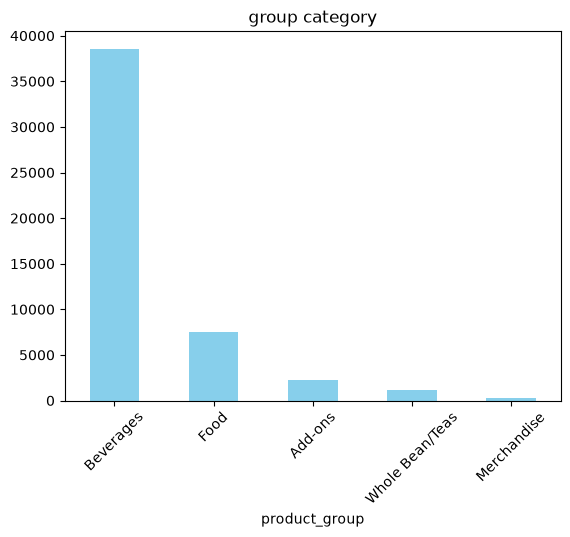

In [209]:
coffee_df['product_group'].value_counts().plot(kind = 'bar', title = 'group category', rot = 45, color = (0.53,0.81,0.92));

##### 27.❓Can you calculate the median profit for each product type?

In [210]:
coffee_df.groupby('product_type')['profit'].median()

product_type
Barista Espresso          3.40
Biscotti                  1.22
Black tea                 1.79
Brewed Black tea          3.74
Brewed Chai tea           3.74
Brewed Green tea          3.74
Brewed herbal tea         3.74
Chai tea                  1.90
Clothing                 19.04
Drinking Chocolate        2.67
Drip coffee               2.40
Espresso Beans            2.95
Gourmet Beans             4.20
Gourmet brewed coffee     3.20
Green beans               2.00
Green tea                 1.85
Herbal tea                1.79
Hot chocolate             1.74
House blend Beans         3.60
Housewares                9.52
Organic Beans             3.60
Organic Chocolate         1.52
Organic brewed coffee     3.52
Pastry                    1.31
Premium Beans             9.00
Premium brewed coffee     3.92
Regular syrup             1.52
Scone                     1.14
Sugar free syrup          1.52
Name: profit, dtype: float64

##### 28.❓Create a column that shows the transaction_day



In [213]:
coffee_df['transaction_day'] = coffee_df['transaction_date'].dt.day
coffee_df

,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation,total_wholesale_amount,profit,profit_ratio,transaction_day
0,2019-04-01,12:04:43,558.0,1,2.50,2.50,Beverages,Tea,Brewed Chai tea,0.63,2018-06-19,1983.0,Older Millennials,0.63,1.87,3.968254,1
1,2019-04-01,11:15:38,22.0,1,2.50,2.50,Beverages,Tea,Brewed Chai tea,0.63,2017-03-03,1953.0,Baby Boomers,0.63,1.87,3.968254,1
2,2019-04-01,12:05:31,659.0,2,5.00,2.50,Beverages,Tea,Brewed Chai tea,0.63,2019-01-14,1996.0,Gen Z,1.26,3.74,3.968254,1
3,2019-04-01,16:49:38,407.0,1,2.50,2.50,Beverages,Tea,Brewed Chai tea,0.63,2017-08-11,1963.0,Baby Boomers,0.63,1.87,3.968254,1
4,2019-04-01,19:17:34,537.0,2,5.00,2.50,Beverages,Tea,Brewed Chai tea,0.63,2018-05-06,1980.0,Older Millennials,1.26,3.74,3.968254,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49889,2019-04-24,09:31:54,8113.0,1,8.95,8.95,Whole Bean/Teas,Loose Tea,Herbal tea,7.16,2017-01-08,1998.0,Gen Z,7.16,1.79,1.250000,24
49890,2019-04-25,06:17:12,5778.0,1,8.95,8.95,Whole Bean/Teas,Loose Tea,Herbal tea,7.16,2017-04-08,1956.0,Baby Boomers,7.16,1.79,1.250000,25
49891,2019-04-25,10:48:21,NaN,1,8.95,8.95,Whole Bean/Teas,Loose Tea,Herbal tea,7.16,NaT,NaN,NaN,7.16,1.79,1.250000,25
49892,2019-04-25,08:54:27,8039.0,1,8.95,8.95,Whole Bean/Teas,Loose Tea,Herbal tea,7.16,2017-06-26,1963.0,Baby Boomers,7.16,1.79,1.250000,25


##### 29.❓Is there a relationship between the day of the week and the total sale revenue? How could you explain any relationship you can see in the data?
*hint*: total sale revenue is the line_item_amount column

In [214]:
coffee_df.groupby('transaction_day')['line_item_amount'].sum().sort_values(ascending = False)

transaction_day
17    9828.55
19    8939.89
24    8857.75
27    8756.58
8     8751.29
13    8710.26
18    8692.78
15    8663.64
16    8589.04
26    8430.88
21    8384.26
25    8340.85
9     8262.53
23    8251.14
22    8244.41
10    8226.48
14    8183.86
20    8158.26
11    7782.74
7     7698.48
12    7697.53
1     7462.00
3     7461.25
2     7269.10
5     7236.25
4     7086.45
28    6748.15
6     6513.75
29    6442.40
Name: line_item_amount, dtype: float64

##### 30.❓Can you make a bar chart for the previous step?

_🎨 Visualize your results 🎨_

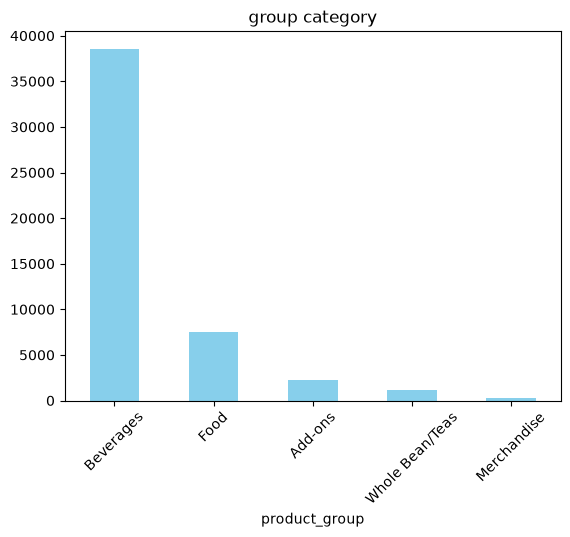

In [215]:
coffee_df['product_group'].value_counts().plot(kind = 'bar', title = 'group category', rot = 45, color = (0.53,0.81,0.92));

##### Write your findings here please:
👉 More transactions on Monday suggest a "back to work blues" effect

##### 31.❓The client suspects that the Gen Z customer cohort spends the most. Can you test this out and confirm whether it's true or not?

In [216]:
coffee_df.groupby(by = 'customer_generation')['line_item_amount'].sum().sort_values(ascending = False)

customer_generation
Baby Boomers           27295.04
Gen X                  26739.61
Older Millennials      25166.90
Gen Z                  19716.40
Younger Millennials    15414.78
Name: line_item_amount, dtype: float64

##### 32.❓Prove previous step by plotting a bar chart

_🎨 Visualize your results 🎨_

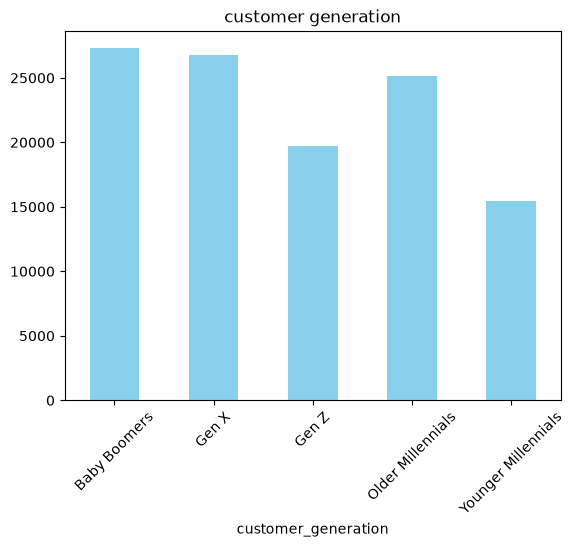

In [217]:
coffee_df.groupby(by = 'customer_generation')['line_item_amount'].sum().plot(kind = 'bar', title = 'customer generation', rot = 45, color = (0.53,0.81,0.92));

##### 33.❓ Is GenZ spend the most as suspected? 
##### Write your findings here please:

👉 It looks like the opposite, Gen Z spend the second lowest in total.
-- -

## Part B 
In this section explore the coffee shop data to answer the following questions : 
1. **What kinds of products type generate the most profit? show top 5 only. Plot a chart to show the result**
2. **What segment of customers generate the most profit ratio? Plot a chart to show the result**


##### 1.❓What kinds of products type generate the most profit? show top 5 only


In [218]:
coffee_df.groupby(by = 'product_type')['profit'].sum().sort_values(ascending = False).head()

product_type
Barista Espresso         24510.50
Brewed Chai tea          19224.25
Gourmet brewed coffee    18944.72
Brewed Black tea         11950.33
Brewed herbal tea        11829.56
Name: profit, dtype: float64

##### 2.❓Plot a chart to show the above result

_🎨 Visualize your results 🎨_

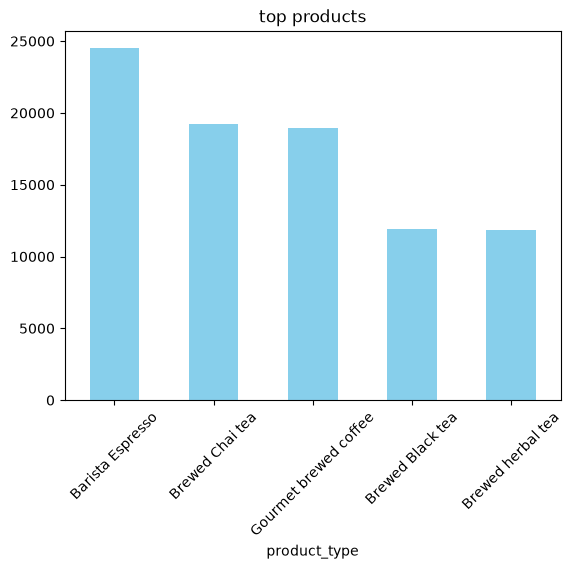

In [219]:
coffee_df.groupby(by = 'product_type')['profit'].sum().sort_values(ascending = False).head().plot(kind = 'bar', title = 'top products', rot = 45, color = (0.53,0.81,0.92));

##### 3.❓What segment of customers generate the most profit ratio? 

*Hint*: Show the average of profit ratio

In [220]:
coffee_df.groupby(by = 'customer_generation')['profit_ratio'].mean()

customer_generation
Baby Boomers           4.314711
Gen X                  4.227303
Gen Z                  4.296470
Older Millennials      4.244458
Younger Millennials    4.200466
Name: profit_ratio, dtype: float64

##### 4.❓Plot a chart to show the above result

_🎨 Visualize your results 🎨_

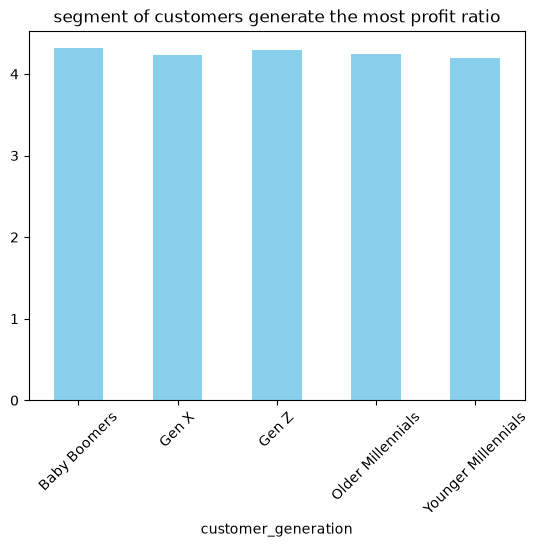

In [221]:
coffee_df.groupby(by = 'customer_generation')['profit_ratio'].mean().plot(kind = 'bar', title = 'segment of customers generate the most profit ratio', rot = 45, color = (0.53,0.81,0.92));

In [222]:
coffee_df.head()

,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation,total_wholesale_amount,profit,profit_ratio,transaction_day
0,2019-04-01,12:04:43,558.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-06-19,1983.0,Older Millennials,0.63,1.87,3.968254,1
1,2019-04-01,11:15:38,22.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-03-03,1953.0,Baby Boomers,0.63,1.87,3.968254,1
2,2019-04-01,12:05:31,659.0,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2019-01-14,1996.0,Gen Z,1.26,3.74,3.968254,1
3,2019-04-01,16:49:38,407.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-08-11,1963.0,Baby Boomers,0.63,1.87,3.968254,1
4,2019-04-01,19:17:34,537.0,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-05-06,1980.0,Older Millennials,1.26,3.74,3.968254,1




## Part C : Dig Deeper

In this section you are going to be doing your own analysis to answer this 3 main questions :
##### 1.❓Are there better or worse days/times in terms of sales? Plot a chart to show the result

In [224]:
# Extracting dates from transaction date
coffee_df['day_of_week'] = coffee_df['transaction_date'].dt.day_name()
coffee_df.head()

,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation,total_wholesale_amount,profit,profit_ratio,transaction_day,day_of_week
0,2019-04-01,12:04:43,558.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-06-19,1983.0,Older Millennials,0.63,1.87,3.968254,1,Monday
1,2019-04-01,11:15:38,22.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-03-03,1953.0,Baby Boomers,0.63,1.87,3.968254,1,Monday
2,2019-04-01,12:05:31,659.0,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2019-01-14,1996.0,Gen Z,1.26,3.74,3.968254,1,Monday
3,2019-04-01,16:49:38,407.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-08-11,1963.0,Baby Boomers,0.63,1.87,3.968254,1,Monday
4,2019-04-01,19:17:34,537.0,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-05-06,1980.0,Older Millennials,1.26,3.74,3.968254,1,Monday


In [226]:
coffee_df.info()

<class 'pandas.DataFrame'>
Index: 49745 entries, 0 to 49893
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   transaction_date         49745 non-null  datetime64[us]
 1   transaction_time         49745 non-null  str           
 2   customer_id              24801 non-null  float64       
 3   quantity                 49745 non-null  int64         
 4   line_item_amount         49745 non-null  float64       
 5   unit_price               49745 non-null  float64       
 6   product_group            49745 non-null  str           
 7   product_category         49745 non-null  str           
 8   product_type             49745 non-null  str           
 9   current_wholesale_price  49745 non-null  float64       
 10  customer_since           24792 non-null  datetime64[us]
 11  customer_birth_year      24792 non-null  float64       
 12  customer_generation      24792 non-null  str    

In [227]:
# Creating time categories function to return Morning, Noon, Evenging, Night based on transaction_time

coffee_df['hour'] = coffee_df['transaction_time'].str.split(':').str[0].astype(int)

def get_time_category(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Noon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

# use apply to apply the time category into a new column called time_category
coffee_df['time_category'] = coffee_df['hour'].apply(get_time_category)
coffee_df.head()

,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation,total_wholesale_amount,profit,profit_ratio,transaction_day,day_of_week,hour,time_category
0,2019-04-01,12:04:43,558.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-06-19,1983.0,Older Millennials,0.63,1.87,3.968254,1,Monday,12,Noon
1,2019-04-01,11:15:38,22.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-03-03,1953.0,Baby Boomers,0.63,1.87,3.968254,1,Monday,11,Morning
2,2019-04-01,12:05:31,659.0,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2019-01-14,1996.0,Gen Z,1.26,3.74,3.968254,1,Monday,12,Noon
3,2019-04-01,16:49:38,407.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-08-11,1963.0,Baby Boomers,0.63,1.87,3.968254,1,Monday,16,Noon
4,2019-04-01,19:17:34,537.0,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-05-06,1980.0,Older Millennials,1.26,3.74,3.968254,1,Monday,19,Evening


In [228]:
# Are there better or worse days/times in terms of sales?
coffee_df.groupby('time_category')['line_item_amount'].sum().sort_values(ascending = False)
# Write your findings

time_category
Morning    128536.97
Noon        68893.76
Evening     35714.29
Night         525.53
Name: line_item_amount, dtype: float64

> 👉 **Write Your Findings Here**:  
-- -

In [229]:
# Are there better or worse days/times in terms of sales?

# Sales are highest in the morning, unlike at night when sales are very low

# Write your findings

> 👉 **Write Your Findings Here**: 
-- -

##### 2.❓Does customers’ willingness to pay for `Beverages` product group vary by generation? Plot a chart to show the result

In [234]:
# Does customers’ willingness to pay for Beverages vary by generation?
bev_df = coffee_df[coffee_df['product_group'] == 'Beverages']
gen_data = bev_df.groupby('customer_generation')['unit_price'].mean().reset_index()

# Write your findings

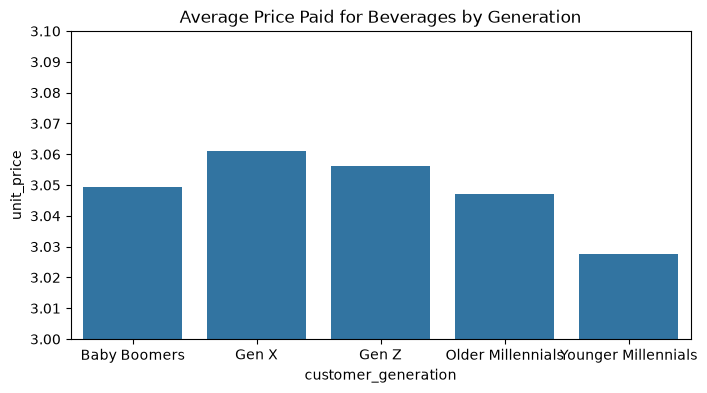

In [237]:
plt.figure(figsize=(8, 4))
sns.barplot(data=gen_data, x='customer_generation', y='unit_price')
plt.title("Average Price Paid for Beverages by Generation")
plt.ylim(3.00, 3.10)
plt.yticks(np.arange(3.00, 3.11, 0.01))
plt.show()

In [238]:
# Gen X has the highest willingness to pay

> 👉 **Write Your Findings Here**: 
-- -

##### 3.❓Do customers who have been customers longer tend to spend more? Plot a chart to show the result (Hint : You may need to use date.today() to get todays date)

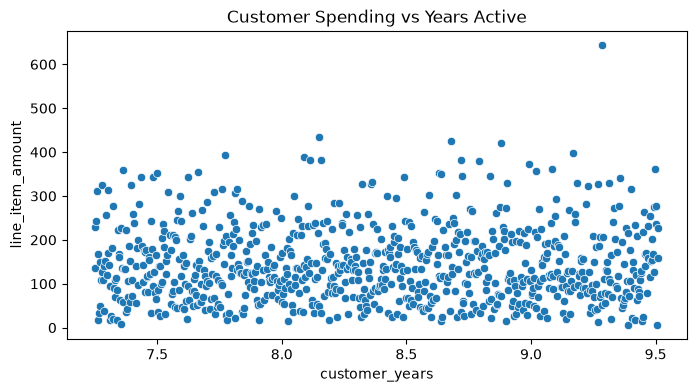

In [246]:
# Do customers who have been customers longer tend to spend more?
today = pd.to_datetime(date.today())
coffee_df['customer_years'] = (today - pd.to_datetime(coffee_df['customer_since'])).dt.days / 365.25

customer_data = coffee_df.groupby('customer_years')['line_item_amount'].sum().reset_index()

plt.figure(figsize=(8, 4))
sns.scatterplot(data=customer_data, x='customer_years', y='line_item_amount')
plt.title("Customer Spending vs Years Active")
plt.show()

# I used Ai to help me in this question 